<a href="https://colab.research.google.com/github/lokeshneerasa/Numpyyy/blob/main/%E2%9A%A1_Electricity_Consumption_Analysis_Using_NumPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **-------------  Electricity Consumption Analysis --------------**

# **Step-1-->Import the required libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


# **Step-2-->Upload the CSV file**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving electricity_consumption_2025.csv to electricity_consumption_2025.csv


# **Step-3-->Read the dataset**

In [3]:
df = pd.read_csv("electricity_consumption_2025.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


# **Step-4 -->Display the first 10 records**

In [4]:
print(df.head(10))

         Date  AC_kWh  Refrigerator_kWh  WashingMachine_kWh  TV_kWh  \
0  2025-01-01    5.00              1.58                0.50    0.56   
1  2025-01-02    9.61              2.44                1.67    0.63   
2  2025-01-03    7.86              2.36                1.40    0.58   
3  2025-01-04    6.79              1.29                1.14    1.47   
4  2025-01-05    3.25              1.10                0.85    0.83   
5  2025-01-06    3.25              1.15                1.78    0.39   
6  2025-01-07    2.46              1.03                0.91    1.75   
7  2025-01-08    8.93              1.14                1.67    1.63   
8  2025-01-09    6.81              2.02                0.99    1.69   
9  2025-01-10    7.66              1.11                0.88    1.79   

   Other_kWh  Total_kWh  
0       2.18       9.82  
1       2.95      17.30  
2       1.32      13.52  
3       2.97      13.66  
4       4.00      10.03  
5       1.14       7.71  
6       3.93      10.08  
7       2.

# **Step-5-->Understand the dataset**

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 365
Number of columns: 7


# **Step-6-->Check column names**

In [6]:
print(df.columns)

Index(['Date', 'AC_kWh', 'Refrigerator_kWh', 'WashingMachine_kWh', 'TV_kWh',
       'Other_kWh', 'Total_kWh'],
      dtype='object')


# **Step-7-->Check missing values**

In [7]:
print(df.isnull().sum())

Date                  0
AC_kWh                0
Refrigerator_kWh      0
WashingMachine_kWh    0
TV_kWh                0
Other_kWh             0
Total_kWh             0
dtype: int64


# **Step-8-->Convert Date column**

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].head())

0   2025-01-01
1   2025-01-02
2   2025-01-03
3   2025-01-04
4   2025-01-05
Name: Date, dtype: datetime64[ns]


# **Step-9-->convert data to NumPy**

In [9]:
ac = df["AC_kWh"].to_numpy()
refrigerator = df["Refrigerator_kWh"].to_numpy()
washing_machine = df["WashingMachine_kWh"].to_numpy()
tv = df["TV_kWh"].to_numpy()
other = df["Other_kWh"].to_numpy()
total = df["Total_kWh"].to_numpy()

print("AC array:")
print(ac[:10])

print("\nTotal consumption array:")
print(total[:10])

AC array:
[5.   9.61 7.86 6.79 3.25 3.25 2.46 8.93 6.81 7.66]

Total consumption array:
[ 9.82 17.3  13.52 13.66 10.03  7.71 10.08 15.59 15.12 14.79]


# **Step-10-->Understand NumPy arrays**

In [10]:
print("Type:", type(total))
print("Shape:", total.shape)
print("Size:", total.size)
print("Data type:", total.dtype)

Type: <class 'numpy.ndarray'>
Shape: (365,)
Size: 365
Data type: float64


# **Step-11--> Calculate total yearly consumption**

In [11]:
total_yearly_consumption = np.sum(total)

print("Total electricity consumption in 2025:",
      round(total_yearly_consumption, 2), "kWh")

Total electricity consumption in 2025: 4902.27 kWh


# **Step-12-->Calculate average daily consumption**

In [12]:
average_daily = np.mean(total)

print("Average daily electricity consumption:",
      round(average_daily, 2), "kWh")

Average daily electricity consumption: 13.43 kWh


# **Step-13-->Find minimum consumption**

In [13]:
minimum_consumption = np.min(total)

print("Minimum daily consumption:",
      round(minimum_consumption, 2), "kWh")

Minimum daily consumption: 5.85 kWh


# **Step-14-->Find maximum consumption**

In [14]:
maximum_consumption = np.max(total)

print("Maximum daily consumption:",
      round(maximum_consumption, 2), "kWh")

Maximum daily consumption: 19.89 kWh


# **Step-15-->Find the day with maximum consumption**

In [15]:
max_index = np.argmax(total)

max_date = df["Date"].iloc[max_index]
max_value = total[max_index]

print("Highest consumption date:", max_date.date())
print("Highest consumption:", round(max_value, 2), "kWh")

Highest consumption date: 2025-04-24
Highest consumption: 19.89 kWh


**np.argmax():** It gives the position/index of the largest value.

In [16]:
a = np.array([10, 50, 20, 30])

print(np.argmax(a))

1


# **Step-16-->Find the day with minimum consumption**

In [17]:
min_index = np.argmin(total)

min_date = df["Date"].iloc[min_index]
min_value = total[min_index]

print("Lowest consumption date:", min_date.date())
print("Lowest consumption:", round(min_value, 2), "kWh")

Lowest consumption date: 2025-02-12
Lowest consumption: 5.85 kWh


# **Step-17-->Calculate appliance-wise consumption**

In [18]:
appliance_names = np.array([
    "AC",
    "Refrigerator",
    "Washing Machine",
    "TV",
    "Other"
])

appliance_consumption = np.array([
    np.sum(ac),
    np.sum(refrigerator),
    np.sum(washing_machine),
    np.sum(tv),
    np.sum(other)
])

for name, consumption in zip(appliance_names, appliance_consumption):
    print(name, ":", round(consumption, 2), "kWh")

AC : 2574.51 kWh
Refrigerator : 635.83 kWh
Washing Machine : 400.43 kWh
TV : 388.94 kWh
Other : 902.56 kWh


# **Step-18-->Find the highest-consuming appliance**

In [19]:
highest_appliance_index = np.argmax(appliance_consumption)

highest_appliance = appliance_names[highest_appliance_index]
highest_appliance_value = appliance_consumption[highest_appliance_index]

print("Highest consuming appliance:",
      highest_appliance)

print("Consumption:",
      round(highest_appliance_value, 2), "kWh")

Highest consuming appliance: AC
Consumption: 2574.51 kWh


# **Step-19-->Calculate appliance consumption percentage**

In [20]:
percentage = (appliance_consumption / total_yearly_consumption) * 100

for name, percent in zip(appliance_names, percentage):
    print(name, ":", round(percent, 2), "%")

AC : 52.52 %
Refrigerator : 12.97 %
Washing Machine : 8.17 %
TV : 7.93 %
Other : 18.41 %


# **Step-20-->Create an appliance analysis table**

In [21]:
appliance_analysis = pd.DataFrame({
    "Appliance": appliance_names,
    "Consumption_kWh": np.round(appliance_consumption, 2),
    "Percentage": np.round(percentage, 2)
})

print(appliance_analysis)

         Appliance  Consumption_kWh  Percentage
0               AC          2574.51       52.52
1     Refrigerator           635.83       12.97
2  Washing Machine           400.43        8.17
3               TV           388.94        7.93
4            Other           902.56       18.41


# **Step-21-->Find high-consumption days**

In [22]:
high_consumption = total > 15

print("Number of high-consumption days:",
      np.sum(high_consumption))

Number of high-consumption days: 120


# **Step-22-->Display high-consumption days**

In [23]:
high_days = df[high_consumption]

print(high_days[["Date", "Total_kWh"]])

          Date  Total_kWh
1   2025-01-02      17.30
7   2025-01-08      15.59
8   2025-01-09      15.12
11  2025-01-12      16.88
12  2025-01-13      16.32
..         ...        ...
345 2025-12-12      15.11
351 2025-12-18      16.09
355 2025-12-22      15.54
358 2025-12-25      17.64
364 2025-12-31      15.62

[120 rows x 2 columns]


# **Step-23-->Calculate percentage of high-consumption days**

In [24]:
high_day_percentage = (np.sum(high_consumption) / len(total)) * 100

print("Percentage of high-consumption days:",
      round(high_day_percentage, 2), "%")

Percentage of high-consumption days: 32.88 %


# **Step-24-->Calculate standard deviation**

In [25]:
std_consumption = np.std(total)

print("Standard deviation:",
      round(std_consumption, 2), "kWh")

Standard deviation: 2.91 kWh


# **Step-25-->Calculate median consumption**

In [26]:
median_consumption = np.median(total)

print("Median daily consumption:",
      round(median_consumption, 2), "kWh")

Median daily consumption: 13.49 kWh


# **Step-26-->Calculate percentiles**

In [27]:
p25 = np.percentile(total, 25)
p50 = np.percentile(total, 50)
p75 = np.percentile(total, 75)
p90 = np.percentile(total, 90)

print("25th percentile:", round(p25, 2), "kWh")
print("50th percentile:", round(p50, 2), "kWh")
print("75th percentile:", round(p75, 2), "kWh")
print("90th percentile:", round(p90, 2), "kWh")

25th percentile: 11.25 kWh
50th percentile: 13.49 kWh
75th percentile: 15.59 kWh
90th percentile: 17.21 kWh


# **Step-27-->Calculate monthly consumption**

In [28]:
df["Month"] = df["Date"].dt.month

monthly_consumption = df.groupby("Month")["Total_kWh"].sum()

print(monthly_consumption)

Month
1     378.44
2     349.74
3     380.66
4     463.93
5     470.08
6     444.54
7     463.23
8     449.04
9     388.62
10    370.27
11    374.18
12    369.54
Name: Total_kWh, dtype: float64


# **Step-28-->Convert monthly data to NumPy**

In [29]:
monthly_values = monthly_consumption.to_numpy()

print(monthly_values)

[378.44 349.74 380.66 463.93 470.08 444.54 463.23 449.04 388.62 370.27
 374.18 369.54]


# **Step-29-->Find highest-consuming month**

In [30]:
highest_month_index = np.argmax(monthly_values)

highest_month = monthly_consumption.index[highest_month_index]
highest_month_value = monthly_values[highest_month_index]

print("Highest consumption month:",
      highest_month)

print("Consumption:",
      round(highest_month_value, 2), "kWh")

Highest consumption month: 5
Consumption: 470.08 kWh


# **Step-30-->Find lowest-consuming month**

In [31]:
lowest_month_index = np.argmin(monthly_values)

lowest_month = monthly_consumption.index[lowest_month_index]
lowest_month_value = monthly_values[lowest_month_index]

print("Lowest consumption month:",
      lowest_month)

print("Consumption:",
      round(lowest_month_value, 2), "kWh")

Lowest consumption month: 2
Consumption: 349.74 kWh


# **Step-31-->. Monthly average**

In [32]:
monthly_average = np.mean(monthly_values)

print("Average monthly consumption:",
      round(monthly_average, 2), "kWh")

Average monthly consumption: 408.52 kWh


# **Step-32-->Electricity bill estimation**

In [33]:
cost_per_kwh = 8

estimated_bill = total_yearly_consumption * cost_per_kwh

print("Estimated yearly electricity cost: ₹",
      round(estimated_bill, 2))

Estimated yearly electricity cost: ₹ 39218.16


# **Step-33-->Estimate average monthly bill**

In [34]:
average_monthly_bill = estimated_bill / 12

print("Estimated average monthly bill: ₹",
      round(average_monthly_bill, 2))

Estimated average monthly bill: ₹ 3268.18


# **Step-34-->Find days where consumption is above average**

In [35]:
above_average = total > average_daily

print("Number of days above average:",
      np.sum(above_average))

Number of days above average: 184


# **Step-35-->Display above-average days**

In [36]:
above_average_days = df[above_average]

print(above_average_days[["Date", "Total_kWh"]].head(20))

         Date  Total_kWh
1  2025-01-02      17.30
2  2025-01-03      13.52
3  2025-01-04      13.66
7  2025-01-08      15.59
8  2025-01-09      15.12
9  2025-01-10      14.79
11 2025-01-12      16.88
12 2025-01-13      16.32
18 2025-01-19      14.11
20 2025-01-21      14.13
25 2025-01-26      16.13
27 2025-01-28      13.51
28 2025-01-29      14.39
33 2025-02-03      15.34
34 2025-02-04      15.62
35 2025-02-05      15.24
39 2025-02-09      13.59
43 2025-02-13      15.59
47 2025-02-17      14.01
48 2025-02-18      13.70


# **Step-36-->Calculate daily change in consumption**

In [37]:
daily_change = np.diff(total)

print("First 10 daily changes:")
print(np.round(daily_change[:10], 2))

First 10 daily changes:
[ 7.48 -3.78  0.14 -3.63 -2.32  2.37  5.51 -0.47 -0.33 -6.86]


# **Step-37-->Find the biggest increase in consumption**

In [38]:
increase_index = np.argmax(daily_change)

print("Largest increase occurred on:",
      df["Date"].iloc[increase_index + 1].date())

print("Increase:",
      round(daily_change[increase_index], 2), "kWh")

Largest increase occurred on: 2025-02-13
Increase: 9.74 kWh


# **Step-38-->Find the biggest decrease**

In [39]:
decrease_index = np.argmin(daily_change)

print("Largest decrease occurred on:",
      df["Date"].iloc[decrease_index + 1].date())

print("Decrease:",
      round(daily_change[decrease_index], 2), "kWh")

Largest decrease occurred on: 2025-06-18
Decrease: -8.44 kWh


# **Step-39-->NumPy sorting**

In [40]:
sorted_indices = np.argsort(total)

top_10_indices = sorted_indices[-10:][::-1]

print("Top 10 highest consumption days:\n")

for index in top_10_indices:
    print(
        df["Date"].iloc[index].date(),
        "->",
        round(total[index], 2),
        "kWh"
    )

Top 10 highest consumption days:

2025-04-24 -> 19.89 kWh
2025-08-29 -> 19.84 kWh
2025-08-08 -> 19.28 kWh
2025-05-11 -> 19.03 kWh
2025-05-20 -> 19.02 kWh
2025-05-04 -> 18.91 kWh
2025-07-29 -> 18.86 kWh
2025-07-22 -> 18.63 kWh
2025-04-30 -> 18.56 kWh
2025-11-10 -> 18.53 kWh


# **Step-40-->Create a complete summary**

In [41]:
print("=" * 50)
print(" ELECTRICITY CONSUMPTION ANALYSIS")
print("=" * 50)

print("Total yearly consumption:",
      round(total_yearly_consumption, 2), "kWh")

print("Average daily consumption:",
      round(average_daily, 2), "kWh")

print("Minimum daily consumption:",
      round(minimum_consumption, 2), "kWh")

print("Maximum daily consumption:",
      round(maximum_consumption, 2), "kWh")

print("Median daily consumption:",
      round(median_consumption, 2), "kWh")

print("Standard deviation:",
      round(std_consumption, 2), "kWh")

print("Highest consuming appliance:",
      highest_appliance)

print("High-consumption days:",
      np.sum(high_consumption))

print("Estimated yearly electricity cost: ₹",
      round(estimated_bill, 2))

print("Estimated average monthly bill: ₹",
      round(average_monthly_bill, 2))

print("=" * 50)

 ELECTRICITY CONSUMPTION ANALYSIS
Total yearly consumption: 4902.27 kWh
Average daily consumption: 13.43 kWh
Minimum daily consumption: 5.85 kWh
Maximum daily consumption: 19.89 kWh
Median daily consumption: 13.49 kWh
Standard deviation: 2.91 kWh
Highest consuming appliance: AC
High-consumption days: 120
Estimated yearly electricity cost: ₹ 39218.16
Estimated average monthly bill: ₹ 3268.18


# **Step-41-->Visualization — Daily electricity consumption**

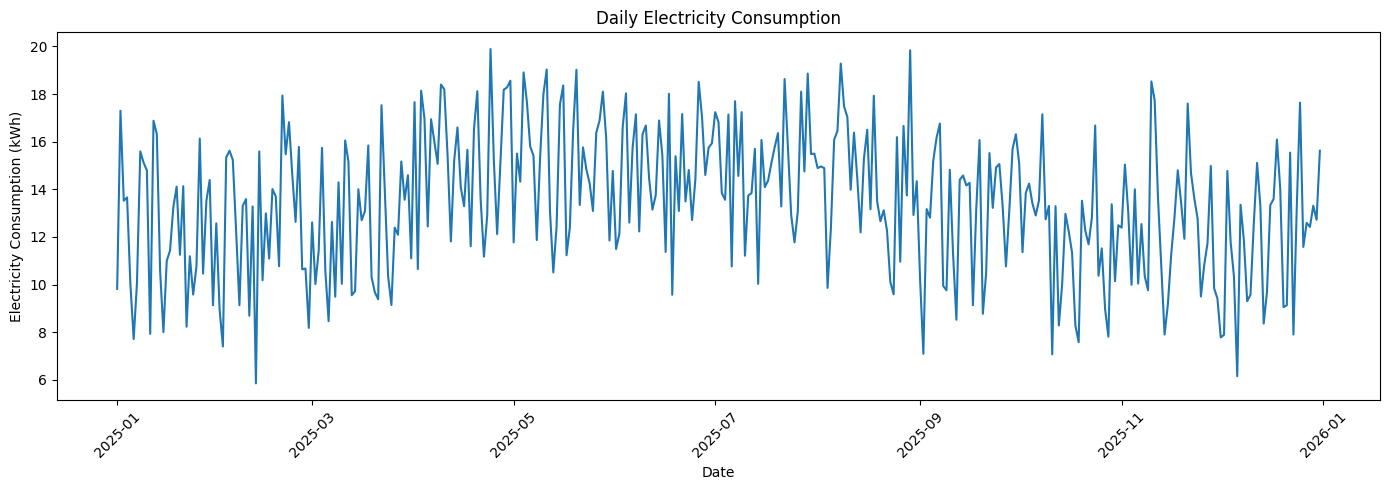

In [42]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], total)

plt.title("Daily Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Electricity Consumption (kWh)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# **Step-42-->Visualization — Appliance consumption**

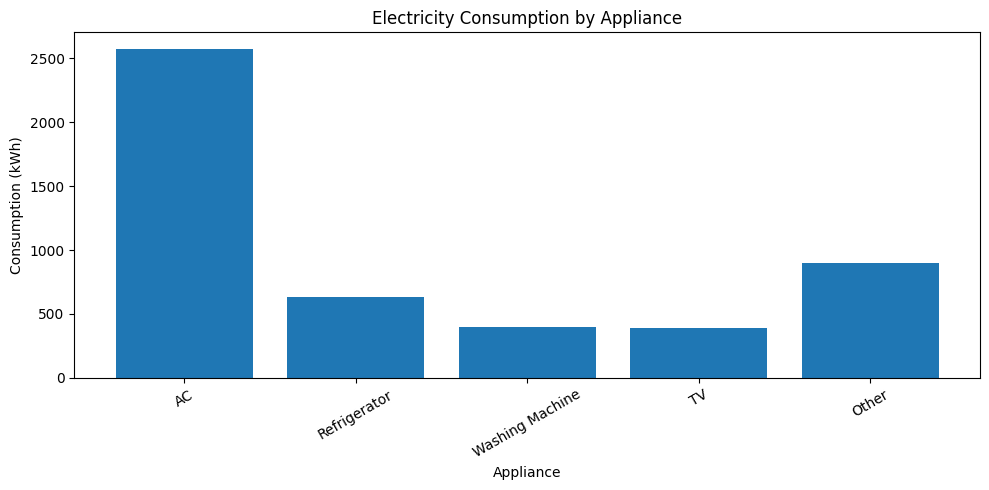

In [43]:
plt.figure(figsize=(10, 5))

plt.bar(appliance_names, appliance_consumption)

plt.title("Electricity Consumption by Appliance")
plt.xlabel("Appliance")
plt.ylabel("Consumption (kWh)")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

# **Step-43-->Visualization — Monthly consumption**

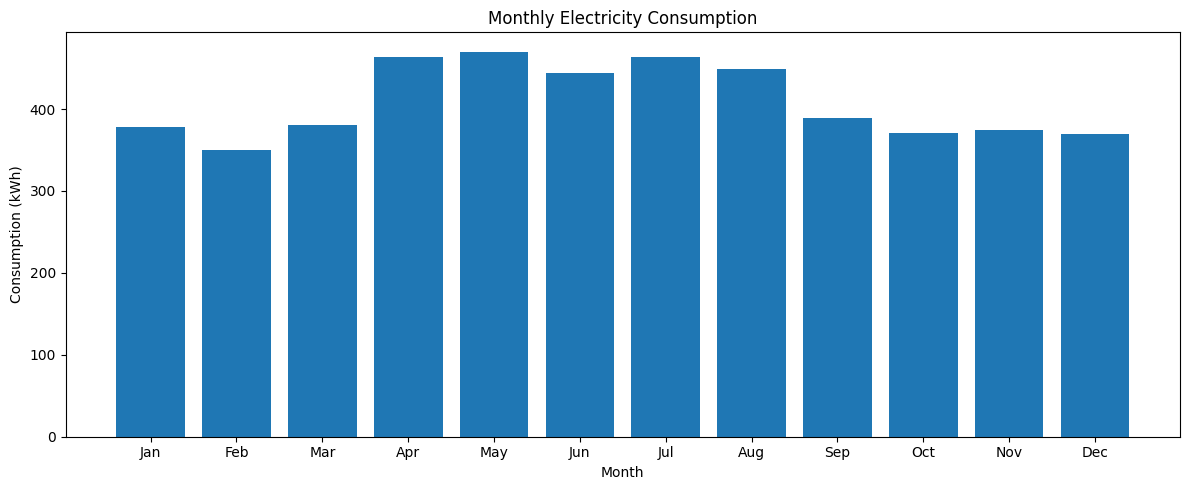

In [44]:
month_names = np.array([
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
])

plt.figure(figsize=(12, 5))

plt.bar(month_names, monthly_values)

plt.title("Monthly Electricity Consumption")
plt.xlabel("Month")
plt.ylabel("Consumption (kWh)")

plt.tight_layout()

plt.show()

# **Step-44-->Visualization — High consumption days**

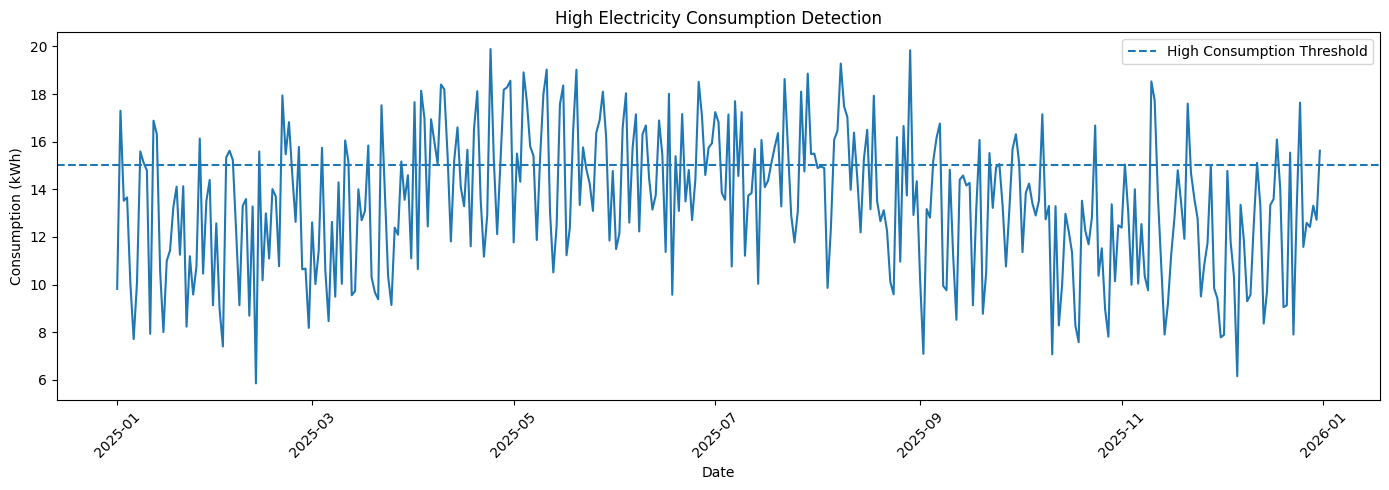

In [45]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], total)

plt.axhline(
    y=15,
    linestyle="--",
    label="High Consumption Threshold"
)

plt.title("High Electricity Consumption Detection")
plt.xlabel("Date")
plt.ylabel("Consumption (kWh)")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# **Step-45-->Visualization — Appliance percentage**

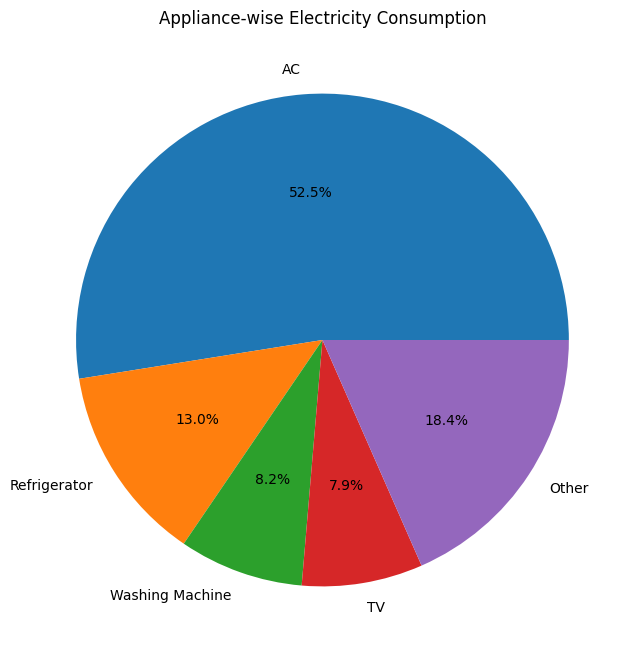

In [46]:
plt.figure(figsize=(8, 8))

plt.pie(
    percentage,
    labels=appliance_names,
    autopct="%1.1f%%"
)

plt.title("Appliance-wise Electricity Consumption")

plt.show()